In [23]:
# Re-initialize FTLE calculator with fixed wind data
print("🔧 Re-initializing FTLE calculator with fixed data...")

ftle_calc = FTLECalculator(
    u_wind_region, v_wind_region,
    times_hours,
    u_wind_region.latitude.values,
    u_wind_region.longitude.values
)

print("✅ FTLE calculator re-initialized successfully!")
print(f"Grid dimensions: {[len(g) for g in ftle_calc.u_interp.grid]}")

# Test the fix
test_pos = [200.0, 50.0]  # [lon, lat]
print(f"\n🧪 Testing velocity at {test_pos}:")
try:
    test_vel = ftle_calc.velocity_field(0.0, test_pos)
    print(f"✅ Success! Velocity: {test_vel} deg/h")
except Exception as e:
    print(f"❌ Still error: {e}")

🔧 Re-initializing FTLE calculator with fixed data...
✅ FTLE calculator re-initialized successfully!
Grid dimensions: [4, 201, 481]

🧪 Testing velocity at [200.0, 50.0]:
✅ Success! Velocity: [0.19159632 0.73050312] deg/h


In [22]:
# FIX: The longitude array is empty - let's check and fix the wind data selection
print("🔧 FIXING LONGITUDE ISSUE")
print("=" * 50)

# Check original wind data coordinates
print("Original wind data coordinates:")
print(f"u_wind shape: {u_wind.shape}")
print(f"u_wind longitude range: {u_wind.longitude.min().values} to {u_wind.longitude.max().values}")
print(f"u_wind longitude count: {len(u_wind.longitude)}")

# Check the regional selection
print(f"\nRegional bounds used:")
print(f"lat_min={lat_min}, lat_max={lat_max}")
print(f"lon_min={lon_min}, lon_max={lon_max}")

# The issue is likely in the longitude selection - let's fix it
# Re-select the regional data with correct longitude handling
print("\n🔧 Re-selecting wind data with proper longitude bounds...")

# Convert longitude to 0-360 if needed for proper selection
u_wind_360 = u_wind.assign_coords(longitude=(u_wind.longitude % 360))
v_wind_360 = v_wind.assign_coords(longitude=(v_wind.longitude % 360))

# Convert bounds to 0-360 as well
lon_min_360 = lon_min % 360
lon_max_360 = lon_max % 360

print(f"Converted longitude bounds: {lon_min_360} to {lon_max_360}")

# Re-select with proper longitude bounds
u_wind_region = u_wind_360.sel(
    latitude=slice(lat_max, lat_min),  # Descending for ERA5
    longitude=slice(lon_min_360, lon_max_360)
)

v_wind_region = v_wind_360.sel(
    latitude=slice(lat_max, lat_min),  # Descending for ERA5
    longitude=slice(lon_min_360, lon_max_360)
)

print(f"\nFixed wind data shapes:")
print(f"u_wind_region shape: {u_wind_region.shape}")
print(f"v_wind_region shape: {v_wind_region.shape}")
print(f"longitude range: {u_wind_region.longitude.min().values} to {u_wind_region.longitude.max().values}")
print(f"longitude count: {len(u_wind_region.longitude)}")

# Update coordinate arrays
times_hours = np.array([(t - time_ref).astype('timedelta64[h]').astype(float) 
                        for t in u_wind_region.valid_time.values])

print(f"\nUpdated coordinates:")
print(f"times_hours: {times_hours}")
print(f"lats shape: {u_wind_region.latitude.values.shape}")
print(f"lons shape: {u_wind_region.longitude.values.shape}")

🔧 FIXING LONGITUDE ISSUE
Original wind data coordinates:
u_wind shape: (4, 721, 1440)
u_wind longitude range: 0.0 to 359.75
u_wind longitude count: 1440

Regional bounds used:
lat_min=20, lat_max=70
lon_min=-180, lon_max=-60

🔧 Re-selecting wind data with proper longitude bounds...
Converted longitude bounds: 180 to 300

Fixed wind data shapes:
u_wind_region shape: (4, 201, 481)
v_wind_region shape: (4, 201, 481)
longitude range: 180.0 to 300.0
longitude count: 481

Updated coordinates:
times_hours: [-43200. -21600.      0.  21600.]
lats shape: (201,)
lons shape: (481,)


In [20]:
# DEBUG: Check data dimensions and interpolator setup
print("🔍 DEBUGGING INTERPOLATOR ERROR")
print("=" * 50)

print("Wind data shapes:")
print(f"u_wind_region shape: {u_wind_region.shape}")
print(f"v_wind_region shape: {v_wind_region.shape}")

print(f"\nCoordinate arrays:")
print(f"times_hours shape: {times_hours.shape}")
print(f"times_hours values: {times_hours}")
print(f"lats shape: {u_wind_region.latitude.values.shape}")
print(f"lons shape: {u_wind_region.longitude.values.shape}")

print(f"\nChecking interpolator grid dimensions:")
try:
    print(f"u_interp grid: {[len(g) for g in ftle_calc.u_interp.grid]}")
    print(f"u_interp values shape: {ftle_calc.u_interp.values.shape}")
except:
    print("Error accessing interpolator grid")

# Test the problematic interpolation call
test_coords = [0.0, 50.0, 200.0]  # [time, lat, lon]
print(f"\nTesting interpolation at {test_coords}:")
try:
    result = ftle_calc.u_interp(test_coords)
    print(f"Success: {result}")
except Exception as e:
    print(f"Error: {e}")
    print(f"Grid lengths: {[len(g) for g in ftle_calc.u_interp.grid]}")
    print(f"Values shape: {ftle_calc.u_interp.values.shape}")

🔍 DEBUGGING INTERPOLATOR ERROR
Wind data shapes:
u_wind_region shape: (4, 201, 0)
v_wind_region shape: (4, 201, 0)

Coordinate arrays:
times_hours shape: (4,)
times_hours values: [-43200. -21600.      0.  21600.]
lats shape: (201,)
lons shape: (0,)

Checking interpolator grid dimensions:
u_interp grid: [4, 201, 0]
u_interp values shape: (4, 201, 0)

Testing interpolation at [0.0, 50.0, 200.0]:
Error: index 0 is out of bounds for axis 0 with size 0
Grid lengths: [4, 201, 0]
Values shape: (4, 201, 0)


In [18]:
# Initialize FTLE calculator if not already defined
if 'ftle_calc' not in globals():
    print("🔧 Initializing FTLE calculator...")
    ftle_calc = FTLECalculator(
        u_wind_region, v_wind_region,
        times_hours,
        u_wind_region.latitude.values,
        u_wind_region.longitude.values
    )
    print("✅ FTLE calculator initialized successfully")
else:
    print("✅ FTLE calculator already exists")

🔧 Initializing FTLE calculator...
✅ FTLE calculator initialized successfully


# FTLE Analysis of 2021 Texas Freeze Blocking Event
## Lagrangian Coherent Structures and Transport Barriers

**Analysis Period:** February 5-14, 2021  
**Focus:** Finite-Time Lyapunov Exponents (FTLE) for blocking-induced transport barriers  
**Data:** ERA5 Reanalysis atmospheric fields  

### Theoretical Background

This analysis applies the methodology from **Schubert & Lucarini (2016)** and **Jensen (2014)** to understand the atmospheric transport structures during the historic Texas freeze of February 2021. 

**Key Concepts:**
- **Blocking Events:** Persistent high-pressure systems that disrupt normal zonal flow
- **FTLE:** Measures local rates of separation of fluid parcels, identifying transport barriers
- **Lagrangian Coherent Structures (LCS):** Material surfaces that organize transport in fluid flows
- **Covariant Lyapunov Vectors (CLVs):** Show how blocking increases global atmospheric instability

**References:**
- Schubert, S. & Lucarini, V. (2016). *Dynamical Analysis of Blocking Events: Spatial and Temporal Fluctuations of Covariant Lyapunov Vectors*
- Jensen, A. D. (2014). *A Dynamic Analysis of a Record Breaking Winter Season Blocking Event*
- Garaboa-Paz et al. (2017). *Climatology of Lyapunov exponents: the link between atmospheric rivers and large-scale mixing variability*

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import subprocess
import traceback
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.integrate import solve_ivp
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import maximum_filter, gaussian_filter
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

print("Libraries imported successfully")
print("Focus: Texas Freeze Blocking Event (Feb 5-14, 2021)")

Libraries imported successfully
Focus: Texas Freeze Blocking Event (Feb 5-14, 2021)


## 1. Load ERA5 Data for Texas Freeze Period

Loading atmospheric data during the Texas freeze blocking event. This extreme weather event was caused by a persistent Arctic blocking pattern that displaced the polar vortex, bringing unprecedented cold temperatures to Texas.

In [2]:
# Smart, memory-efficient data loading for Texas freeze - FIXED LONGITUDE SLICING
# Load only what we need from each file, then combine small pieces

data_path = Path("/scratch/qhuang62/aurora/uri-experiment/data")

# List of files for the Texas freeze period (Feb 5-14, 2021)
dates = ['20210205','20210206','20210207','20210208','20210209',
         '20210210','20210211','20210212','20210213','20210214']

# Check coordinate system from first file to determine proper slicing
test_file = data_path / f"era5_atmospheric_{dates[0]}.nc"
ds_test = xr.open_dataset(test_file, decode_times=False, cache=False)

# Determine longitude slicing based on coordinate system
if ds_test.longitude.min().values < 0:
    # -180 to +180 system: need to handle crossing dateline
    print("📍 Using -180°/+180° coordinate system")
    
    # For North America: 120°E to -60°W (300°E in 0-360 system)
    # Need special handling since we cross 180° dateline
    lon_min_1, lon_max_1 = 120, 180    # Pacific: 120°E to 180°E
    lon_min_2, lon_max_2 = -180, -60   # Americas: 180°W to 60°W
    use_two_slices = True
    
    # Also fix Texas coordinates for -180/+180 system
    texas_lon_min, texas_lon_max = -106, -93  # Already in correct format
    
else:
    # 0 to 360 system: original slicing works
    print("📍 Using 0°/360° coordinate system") 
    lon_min_1, lon_max_1 = 120, 300
    use_two_slices = False
    texas_lon_min, texas_lon_max = 254, 267  # Convert -106/-93 to 0-360

# Latitude domain (include all of Texas)
lat_min, lat_max = 25, 70    # 25N to 70N (includes all of Texas)

ds_test.close()

print(f"📂 Loading Texas freeze data (memory-efficient approach)...")
print(f"🌍 Domain: Lat {lat_min}-{lat_max}°N")
if use_two_slices:
    print(f"🌍 Longitude: {lon_min_1}-{lon_max_1}°E and {lon_min_2}-{lon_max_2}°W")
else:
    print(f"🌍 Longitude: {lon_min_1}-{lon_max_1}°E")

# Load each file, select only what we need immediately, then combine small pieces
daily_winds = []
for date in dates:
    file_path = data_path / f"era5_atmospheric_{date}.nc"
    try:
        ds = xr.open_dataset(file_path, decode_times=False, cache=False)
        
        # Select 300 hPa level first
        ds_300 = ds.sel(pressure_level=300)[['u', 'v']]
        
        # Handle longitude slicing based on coordinate system
        if use_two_slices:
            # Combine two longitude slices for dateline crossing
            ds_1 = ds_300.sel(
                longitude=slice(lon_min_1, lon_max_1),
                latitude=slice(lat_max, lat_min)  # ERA5 lat decreases
            )
            ds_2 = ds_300.sel(
                longitude=slice(lon_min_2, lon_max_2),
                latitude=slice(lat_max, lat_min)
            )
            # Concatenate along longitude dimension
            ds_region = xr.concat([ds_1, ds_2], dim='longitude')
        else:
            # Single longitude slice
            ds_region = ds_300.sel(
                longitude=slice(lon_min_1, lon_max_1),
                latitude=slice(lat_max, lat_min)
            )
        
        daily_winds.append(ds_region)
        ds.close()  # Free memory immediately
        print(f"   ✅ {file_path.name} - extracted 300 hPa winds, shape: {ds_region.u.shape}")
        
    except Exception as e:
        print(f"   ❌ {file_path.name} - SKIPPED: {str(e)[:50]}...")
        continue

# Now combine much smaller datasets
if len(daily_winds) > 0:
    print(f"\n🔗 Combining {len(daily_winds)} wind datasets...")
    ds_winds = xr.concat(daily_winds, dim="valid_time")
    
    # Decode times after combining (safer)
    ds_winds = xr.decode_cf(ds_winds)
    
    # Extract wind components (already at 300 hPa and regional subset)
    u_wind_region = ds_winds['u']
    v_wind_region = ds_winds['v']
    
    print(f"\n✅ Texas Freeze wind data loaded efficiently:")
    print(f"  - Variables: u, v winds at 300 hPa")
    print(f"  - U-wind shape: {u_wind_region.shape}")
    print(f"  - V-wind shape: {v_wind_region.shape}")
    print(f"  - Domain: {lat_min}°N to {lat_max}°N")
    if use_two_slices:
        print(f"  - Longitude: {lon_min_1}°E-{lon_max_1}°E + {lon_min_2}°W-{lon_max_2}°W")
    else:
        print(f"  - Longitude: {lon_min_1}°E to {lon_max_1}°E")
    print(f"  - Time range: {u_wind_region.valid_time.values[0]} to {u_wind_region.valid_time.values[-1]}")
    print(f"  - Memory usage: ~{u_wind_region.nbytes / 1e6:.1f} MB")
    
    # Set global variables for rest of notebook
    if use_two_slices:
        lon_min, lon_max = lon_min_2, lon_max_1  # Full range for plotting
    else:
        lon_min, lon_max = lon_min_1, lon_max_1
    
else:
    raise RuntimeError("No valid data files could be loaded!")

print(f"\n🎯 Ready for FTLE analysis - fixed longitude slicing!")
print(f"🏠 Texas region properly included: {texas_lon_min}°W to {texas_lon_max}°W")

📍 Using 0°/360° coordinate system
📂 Loading Texas freeze data (memory-efficient approach)...
🌍 Domain: Lat 25-70°N
🌍 Longitude: 120-300°E
   ✅ era5_atmospheric_20210205.nc - extracted 300 hPa winds, shape: (4, 181, 721)
   ✅ era5_atmospheric_20210206.nc - extracted 300 hPa winds, shape: (4, 181, 240)
   ✅ era5_atmospheric_20210207.nc - extracted 300 hPa winds, shape: (4, 181, 240)
   ✅ era5_atmospheric_20210208.nc - extracted 300 hPa winds, shape: (4, 181, 240)
   ✅ era5_atmospheric_20210209.nc - extracted 300 hPa winds, shape: (4, 181, 240)
   ✅ era5_atmospheric_20210210.nc - extracted 300 hPa winds, shape: (4, 181, 721)
   ✅ era5_atmospheric_20210211.nc - extracted 300 hPa winds, shape: (4, 181, 240)
   ✅ era5_atmospheric_20210212.nc - extracted 300 hPa winds, shape: (4, 181, 721)
   ✅ era5_atmospheric_20210213.nc - extracted 300 hPa winds, shape: (4, 181, 240)
   ✅ era5_atmospheric_20210214.nc - extracted 300 hPa winds, shape: (4, 181, 721)

🔗 Combining 10 wind datasets...

✅ Texas 

In [3]:
# --- Save as compressed NetCDF (NETCDF4/HDF5) ---
out_nc = Path("/scratch/qhuang62/aurora/uri-experiment/data/tx_freeze_winds_300hpa_subset.nc")

# Build an encoding dict that applies compression to the data variables
encoding = {}
for var in ds_winds.data_vars:
    # use zlib compression and moderate compression level
    encoding[var] = {
        "zlib": True,
        "complevel": 4,       # 1-9 (higher = smaller but slower)
        "shuffle": True,      # often improves compression
        # optionally set dtype if you want to downcast floats (e.g., 'float32')
        # "dtype": "float32"
    }

# Save to disk
ds_winds.to_netcdf(out_nc, format="NETCDF4", encoding=encoding)
print(f"Saved NetCDF: {out_nc}  (size: {out_nc.stat().st_size/1e6:.1f} MB)")

Saved NetCDF: /scratch/qhuang62/aurora/uri-experiment/data/tx_freeze_winds_300hpa_subset.nc  (size: 11.8 MB)


In [4]:
# 🚨 DETAILED DIAGNOSTIC - Step by step troubleshooting
print("🔍 STEP-BY-STEP DIAGNOSTIC")
print("=" * 50)

# Step 1: Check if variables exist
try:
    print(f"✅ u_wind_region exists: {type(u_wind_region)}")
    print(f"✅ v_wind_region exists: {type(v_wind_region)}")
except NameError as e:
    print(f"❌ Variable missing: {e}")
    print("🚨 DATA LOADING FAILED - variables don't exist!")

# Step 2: Check shapes
try:
    print(f"\n📏 Shapes:")
    print(f"   u_wind_region: {u_wind_region.shape}")
    print(f"   v_wind_region: {v_wind_region.shape}")
    
    if 0 in u_wind_region.shape:
        print("🚨 ZERO DIMENSION DETECTED!")
        
except Exception as e:
    print(f"❌ Shape check failed: {e}")

# Step 3: Check coordinate ranges
try:
    print(f"\n🌍 Coordinate ranges:")
    print(f"   Longitude: {u_wind_region.longitude.min().values:.1f}° to {u_wind_region.longitude.max().values:.1f}°")
    print(f"   Latitude: {u_wind_region.latitude.min().values:.1f}° to {u_wind_region.latitude.max().values:.1f}°")
    print(f"   Time steps: {len(u_wind_region.valid_time)}")
    
    if len(u_wind_region.longitude) == 0:
        print("🚨 NO LONGITUDE POINTS!")
    if len(u_wind_region.latitude) == 0:
        print("🚨 NO LATITUDE POINTS!")
        
except Exception as e:
    print(f"❌ Coordinate check failed: {e}")

# Step 4: Check actual data values
try:
    print(f"\n📊 Data values:")
    u_vals = u_wind_region.values
    v_vals = v_wind_region.values
    
    print(f"   U-wind min/max: {np.nanmin(u_vals):.2f} / {np.nanmax(u_vals):.2f}")
    print(f"   V-wind min/max: {np.nanmin(v_vals):.2f} / {np.nanmax(v_vals):.2f}")
    print(f"   Contains NaN? U: {np.isnan(u_vals).any()}, V: {np.isnan(v_vals).any()}")
    print(f"   All zeros? U: {np.all(u_vals == 0)}, V: {np.all(v_vals == 0)}")
    
except Exception as e:
    print(f"❌ Data value check failed: {e}")

# Step 5: Check what happened in data loading
try:
    print(f"\n📁 Data loading variables:")
    print(f"   daily_winds list length: {len(daily_winds) if 'daily_winds' in locals() else 'NOT FOUND'}")
    print(f"   ds_winds exists: {'ds_winds' in locals()}")
    
    if 'daily_winds' in locals() and len(daily_winds) > 0:
        print(f"   First daily_winds shape: {daily_winds[0].u.shape}")
        
except Exception as e:
    print(f"❌ Loading variable check failed: {e}")

print("\n" + "=" * 50)
print("🎯 DIAGNOSIS COMPLETE - Check results above!")

🔍 STEP-BY-STEP DIAGNOSTIC
✅ u_wind_region exists: <class 'xarray.core.dataarray.DataArray'>
✅ v_wind_region exists: <class 'xarray.core.dataarray.DataArray'>

📏 Shapes:
   u_wind_region: (40, 181, 721)
   v_wind_region: (40, 181, 721)

🌍 Coordinate ranges:
   Longitude: 120.0° to 300.0°
   Latitude: 25.0° to 70.0°
   Time steps: 40

📊 Data values:
   U-wind min/max: -55.64 / 108.46
   V-wind min/max: -80.87 / 69.82
   Contains NaN? U: True, V: True
   All zeros? U: False, V: False

📁 Data loading variables:
   daily_winds list length: 10
   ds_winds exists: True
   First daily_winds shape: (4, 181, 721)

🎯 DIAGNOSIS COMPLETE - Check results above!


In [5]:
# 🔍 RAW FILE COORDINATE INSPECTION
print("🗂️ INSPECTING RAW FILE COORDINATES")
print("=" * 50)

# Check first file directly
test_file = data_path / "era5_atmospheric_20210205.nc"
print(f"📁 Opening: {test_file.name}")

try:
    ds_raw = xr.open_dataset(test_file)
    
    print(f"\n📊 Raw file info:")
    print(f"   Variables: {list(ds_raw.data_vars)}")
    print(f"   Coordinates: {list(ds_raw.coords)}")
    print(f"   Pressure levels: {ds_raw.pressure_level.values}")
    
    print(f"\n🌍 Longitude coordinate:")
    lon_coord = ds_raw.longitude
    print(f"   Name: {lon_coord.name}")
    print(f"   Shape: {lon_coord.shape}")
    print(f"   Range: {lon_coord.min().values:.1f}° to {lon_coord.max().values:.1f}°")
    print(f"   First 5: {lon_coord.values[:5]}")
    print(f"   Last 5: {lon_coord.values[-5:]}")
    
    print(f"\n🌍 Latitude coordinate:")
    lat_coord = ds_raw.latitude
    print(f"   Name: {lat_coord.name}")
    print(f"   Shape: {lat_coord.shape}")
    print(f"   Range: {lat_coord.min().values:.1f}° to {lat_coord.max().values:.1f}°")
    print(f"   First 5: {lat_coord.values[:5]}")
    print(f"   Last 5: {lat_coord.values[-5:]}")
    
    # Test slicing manually
    print(f"\n🧪 TESTING LONGITUDE SLICING:")
    
    if lon_coord.min().values < 0:
        print("   Coordinate system: -180° to +180°")
        
        # Test Pacific slice (120°E to 180°E)
        try:
            pacific_slice = ds_raw.sel(longitude=slice(120, 180))
            print(f"   ✅ Pacific slice (120°E-180°E): {len(pacific_slice.longitude)} points")
        except Exception as e:
            print(f"   ❌ Pacific slice failed: {e}")
            
        # Test Americas slice (-180°W to -60°W)  
        try:
            americas_slice = ds_raw.sel(longitude=slice(-180, -60))
            print(f"   ✅ Americas slice (-180°W to -60°W): {len(americas_slice.longitude)} points")
        except Exception as e:
            print(f"   ❌ Americas slice failed: {e}")
            
    else:
        print("   Coordinate system: 0° to 360°")
        try:
            full_slice = ds_raw.sel(longitude=slice(120, 300))
            print(f"   ✅ Full slice (120°E-300°E): {len(full_slice.longitude)} points")
        except Exception as e:
            print(f"   ❌ Full slice failed: {e}")
    
    ds_raw.close()
    
except Exception as e:
    print(f"❌ Raw file inspection failed: {e}")

print("\n" + "=" * 50)
print("🎯 RAW COORDINATE INSPECTION COMPLETE!")

🗂️ INSPECTING RAW FILE COORDINATES
📁 Opening: era5_atmospheric_20210205.nc

📊 Raw file info:
   Variables: ['t', 'u', 'v', 'q', 'z']
   Coordinates: ['number', 'valid_time', 'pressure_level', 'latitude', 'longitude', 'expver']
   Pressure levels: [1000.  925.  850.  700.  600.  500.  400.  300.  250.  200.  150.  100.
   50.]

🌍 Longitude coordinate:
   Name: longitude
   Shape: (1440,)
   Range: 0.0° to 359.8°
   First 5: [0.   0.25 0.5  0.75 1.  ]
   Last 5: [358.75 359.   359.25 359.5  359.75]

🌍 Latitude coordinate:
   Name: latitude
   Shape: (721,)
   Range: -90.0° to 90.0°
   First 5: [90.   89.75 89.5  89.25 89.  ]
   Last 5: [-89.   -89.25 -89.5  -89.75 -90.  ]

🧪 TESTING LONGITUDE SLICING:
   Coordinate system: 0° to 360°
   ✅ Full slice (120°E-300°E): 721 points

🎯 RAW COORDINATE INSPECTION COMPLETE!


In [6]:
# 🔧 SMART FIX - Handle inconsistent longitude grids across files
print("🛠️ APPLYING SMART FIX FOR INCONSISTENT COORDINATE GRIDS")
print("=" * 50)

# The files have different longitude grids - let's standardize them
if len(daily_winds) > 0:
    print(f"✅ Found {len(daily_winds)} daily wind files")
    
    # First, check what longitude grids we have
    print("🔍 Analyzing longitude grids across files:")
    for i, daily_ds in enumerate(daily_winds):
        lons = daily_ds.longitude.values
        print(f"   File {i+1}: {daily_ds.u.shape} | Lon range: {lons.min():.1f}° to {lons.max():.1f}° | {len(lons)} points")
    
    # Find the common longitude domain that all files share
    # Get intersection of all longitude ranges
    all_lon_mins = [daily_ds.longitude.min().values for daily_ds in daily_winds]
    all_lon_maxs = [daily_ds.longitude.max().values for daily_ds in daily_winds]
    
    common_lon_min = max(all_lon_mins)  # Latest start
    common_lon_max = min(all_lon_maxs)  # Earliest end
    
    print(f"\n🎯 Common longitude domain: {common_lon_min:.1f}° to {common_lon_max:.1f}°")
    
    # Use the first file's grid as template and subset all others to match
    template_ds = daily_winds[0]
    
    # Find the longitude slice that works for all files
    template_lons = template_ds.longitude.values
    valid_lon_mask = (template_lons >= common_lon_min) & (template_lons <= common_lon_max)
    common_lons = template_lons[valid_lon_mask]
    
    print(f"📏 Standardized grid: {len(common_lons)} longitude points")
    
    # Now re-slice all files to use the same longitude grid
    print("🔄 Re-slicing all files to common grid...")
    
    u_arrays = []
    v_arrays = []
    time_arrays = []
    
    for i, daily_ds in enumerate(daily_winds):
        # Subset to common longitude range
        daily_subset = daily_ds.sel(longitude=slice(common_lon_min, common_lon_max))
        
        print(f"   File {i+1} after subset: {daily_subset.u.shape}")
        
        u_arrays.append(daily_subset.u.values)
        v_arrays.append(daily_subset.v.values)
        time_arrays.extend(daily_subset.valid_time.values)
    
    # Now concatenation should work
    print("🔗 Concatenating standardized arrays...")
    u_combined = np.concatenate(u_arrays, axis=0)
    v_combined = np.concatenate(v_arrays, axis=0)
    
    print(f"📊 Combined array shapes: u={u_combined.shape}, v={v_combined.shape}")
    
    # Get coordinates from subset
    template_subset = daily_winds[0].sel(longitude=slice(common_lon_min, common_lon_max))
    lats = template_subset.latitude.values
    lons = template_subset.longitude.values
    times = np.array(time_arrays)
    
    print(f"🌍 Final coordinates: times={len(times)}, lats={len(lats)}, lons={len(lons)}")
    
    # Create new DataArrays with proper coordinates
    u_wind_region = xr.DataArray(
        u_combined,
        coords={'valid_time': times, 'latitude': lats, 'longitude': lons},
        dims=['valid_time', 'latitude', 'longitude'],
        name='u'
    )
    
    v_wind_region = xr.DataArray(
        v_combined,
        coords={'valid_time': times, 'latitude': lats, 'longitude': lons},
        dims=['valid_time', 'latitude', 'longitude'],
        name='v'
    )
    
    print(f"\n✅ FIXED DATA ARRAYS (STANDARDIZED GRID):")
    print(f"   u_wind_region: {u_wind_region.shape}")
    print(f"   v_wind_region: {v_wind_region.shape}")
    print(f"   Time range: {u_wind_region.valid_time.values[0]} to {u_wind_region.valid_time.values[-1]}")
    print(f"   Longitude range: {u_wind_region.longitude.min().values:.1f}° to {u_wind_region.longitude.max().values:.1f}°")
    print(f"   Latitude range: {u_wind_region.latitude.min().values:.1f}° to {u_wind_region.latitude.max().values:.1f}°")
    
    # Set domain variables for plotting (use the actual data range)
    lon_min = float(u_wind_region.longitude.min().values)
    lon_max = float(u_wind_region.longitude.max().values)
    lat_min = float(u_wind_region.latitude.min().values)
    lat_max = float(u_wind_region.latitude.max().values)
    
    print(f"\n🎯 Ready for FTLE analysis with standardized grid!")
    print(f"🌍 Domain variables set: lon {lon_min:.1f}-{lon_max:.1f}°, lat {lat_min:.1f}-{lat_max:.1f}°")
    
else:
    print("❌ No daily_winds data found!")

print("=" * 50)

🛠️ APPLYING SMART FIX FOR INCONSISTENT COORDINATE GRIDS
✅ Found 10 daily wind files
🔍 Analyzing longitude grids across files:
   File 1: (4, 181, 721) | Lon range: 120.0° to 300.0° | 721 points
   File 2: (4, 181, 240) | Lon range: 120.0° to 179.8° | 240 points
   File 3: (4, 181, 240) | Lon range: 120.0° to 179.8° | 240 points
   File 4: (4, 181, 240) | Lon range: 120.0° to 179.8° | 240 points
   File 5: (4, 181, 240) | Lon range: 120.0° to 179.8° | 240 points
   File 6: (4, 181, 721) | Lon range: 120.0° to 300.0° | 721 points
   File 7: (4, 181, 240) | Lon range: 120.0° to 179.8° | 240 points
   File 8: (4, 181, 721) | Lon range: 120.0° to 300.0° | 721 points
   File 9: (4, 181, 240) | Lon range: 120.0° to 179.8° | 240 points
   File 10: (4, 181, 721) | Lon range: 120.0° to 300.0° | 721 points

🎯 Common longitude domain: 120.0° to 179.8°
📏 Standardized grid: 240 longitude points
🔄 Re-slicing all files to common grid...
   File 1 after subset: (4, 181, 240)
   File 2 after subset: (4,

## 2. Extract Wind Components at Jet Stream Level

Following the blocking literature, we focus on the **300 hPa level** (jet stream) where blocking patterns are most pronounced. The Texas freeze was associated with a split-flow pattern in the jet stream.

In [7]:
# Select 300 hPa level - primary jet stream level for blocking analysis
pressure_level = 300  # hPa
ds_300 = ds.sel(pressure_level=pressure_level)

# Extract wind components
u_wind = ds_300['u']  # eastward wind (m/s)
v_wind = ds_300['v']  # northward wind (m/s)

# Focus on North American sector where blocking occurred
# Extend domain to capture upstream blocking in Pacific
lon_min, lon_max = -180, -60  # 180E → 60W (Pacific through N. America)
lat_min, lat_max = 20, 70    # 20N to 70N

# Formatters for pretty printing of coordinates
def fmt_lon(lon):
    return f"{abs(lon):.1f}°{'E' if lon >= 0 else 'W'}"

def fmt_lat(lat):
    return f"{abs(lat):.1f}°{'N' if lat >= 0 else 'S'}"
    
# Regional subset for blocking analysis
u_wind_region = u_wind.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min)  # latitude decreases in ERA5
)
v_wind_region = v_wind.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min)
)

# Print summary
print(f"✅ Extracted wind components at {pressure_level} hPa")
print(f"  - U-wind shape: {u_wind_region.shape}")
print(f"  - V-wind shape: {v_wind_region.shape}")
print(f"  - Domain: {fmt_lon(lon_min)} to {fmt_lon(lon_max)}, "
      f"{fmt_lat(lat_min)} to {fmt_lat(lat_max)}")
print(f"  - Time range: {u_wind_region.valid_time.values[0]} "
      f"to {u_wind_region.valid_time.values[-1]}")

✅ Extracted wind components at 300 hPa
  - U-wind shape: (4, 201, 0)
  - V-wind shape: (4, 201, 0)
  - Domain: 180.0°W to 60.0°W, 20.0°N to 70.0°N
  - Time range: 1613260800 to 1613325600


## 3. FTLE Calculation Methodology

### Theoretical Foundation

The **Finite-Time Lyapunov Exponent (FTLE)** quantifies the local rate of separation of fluid parcels:

$$\lambda(\tau, t_0, \mathbf{r}_0) = \frac{1}{|\tau|} \log\sqrt{\mu_{\max}(\mathbf{C})}$$

where:
- $\tau$ is the integration time
- $\mathbf{C}$ is the **Cauchy-Green deformation tensor**
- $\mu_{\max}$ is the maximum eigenvalue of $\mathbf{C}$

The **Cauchy-Green tensor** is defined as:
$$\mathbf{C} = (\nabla\Phi)^T \cdot \mathbf{G} \cdot \nabla\Phi$$

where $\nabla\Phi$ is the flow map gradient and $\mathbf{G}$ is the metric tensor.

**Physical Interpretation:**
- **Forward FTLE** ($\tau > 0$): Identifies **repelling structures** - ridges where parcels separate rapidly
- **Backward FTLE** ($\tau < 0$): Identifies **attracting structures** - ridges where parcels converge
- **LCS ridges** act as transport barriers separating air masses with different origins

In [8]:
class FTLECalculator:
    """
    FTLE Calculator for atmospheric transport analysis
    Based on Garaboa-Paz et al. (2017) methodology
    """
    
    def __init__(self, u_wind, v_wind, times, lats, lons):
        """
        Initialize FTLE calculator
        
        Parameters:
        -----------
        u_wind : xarray.DataArray
            Eastward wind component (time, lat, lon)
        v_wind : xarray.DataArray
            Northward wind component (time, lat, lon)
        times : array
            Time coordinates in hours
        lats : array
            Latitude coordinates
        lons : array
            Longitude coordinates
        """
        self.u_wind = u_wind.values
        self.v_wind = v_wind.values
        self.times = times
        self.lats = lats
        self.lons = lons
        
        # Create interpolators
        self.u_interp = RegularGridInterpolator(
            (times, lats, lons), self.u_wind, 
            method='linear', bounds_error=False, fill_value=0
        )
        self.v_interp = RegularGridInterpolator(
            (times, lats, lons), self.v_wind,
            method='linear', bounds_error=False, fill_value=0
        )
        
        # Earth's mean radius (km)
        self.R_earth = 6371.0
    
    def velocity_field(self, t, pos, backward=False):
        """
        Compute velocity at given position and time
        
        Parameters:
        -----------
        t : float
            Time in hours
        pos : array [lon, lat]
            Position in degrees
        backward : bool
            If True, reverse velocity for backward integration
        
        Returns:
        --------
        velocity : array [dlon/dt, dlat/dt]
            Velocity in degrees per hour
        """
        lon, lat = pos
        
        # Ensure longitude is in [0, 360]
        lon = lon % 360
        
        # Ensure latitude is in valid range
        lat = np.clip(lat, self.lats.min(), self.lats.max())
        
        # Interpolate wind components (m/s)
        u = self.u_interp([t, lat, lon])[0]
        v = self.v_interp([t, lat, lon])[0]
        
        # Convert to degrees per hour
        lat_rad = np.deg2rad(lat)
        dlon_dt = (u / (self.R_earth * 1000 * np.cos(lat_rad))) * (180/np.pi) * 3600
        dlat_dt = (v / (self.R_earth * 1000)) * (180/np.pi) * 3600
        
        velocity = np.array([dlon_dt, dlat_dt])
        
        # Reverse for backward integration
        if backward:
            velocity = -velocity
            
        return velocity
    
    def integrate_trajectory(self, initial_pos, t0, t_final, backward=False):
        """
        Integrate a single particle trajectory
        
        Parameters:
        -----------
        initial_pos : array [lon, lat]
            Initial position
        t0 : float
            Initial time (hours)
        t_final : float
            Final time (hours)
        backward : bool
            Use backward integration
        
        Returns:
        --------
        final_pos : array [lon, lat]
            Final position
        """
        try:
            # Use RK45 (4th-order Runge-Kutta)
            sol = solve_ivp(
                lambda t, pos: self.velocity_field(t, pos, backward=backward),
                (t0, t_final),
                initial_pos,
                method='RK45',
                max_step=1.5,  # 1.5 hour time step
                rtol=1e-6,
                atol=1e-8
            )
            
            if sol.success:
                return sol.y[:, -1]
            else:
                return initial_pos
        except:
            return initial_pos
    
    def compute_flow_map_gradient(self, initial_positions, final_positions, 
                                 grid_shape, grid_spacing):
        """
        Compute flow map gradient using finite differences
        """
        n_lat, n_lon = grid_shape
        final_lon = final_positions[:, 0].reshape(n_lat, n_lon)
        final_lat = final_positions[:, 1].reshape(n_lat, n_lon)
        
        # Initialize gradient array
        grad_phi = np.zeros((n_lat, n_lon, 2, 2))
        
        # Central differences for interior points
        for i in range(1, n_lat-1):
            for j in range(1, n_lon-1):
                # ∂(final_lon)/∂(init_lon)
                grad_phi[i, j, 0, 0] = (final_lon[i, j+1] - final_lon[i, j-1]) / (2 * grid_spacing)
                
                # ∂(final_lon)/∂(init_lat)
                grad_phi[i, j, 0, 1] = (final_lon[i+1, j] - final_lon[i-1, j]) / (2 * grid_spacing)
                
                # ∂(final_lat)/∂(init_lon)
                grad_phi[i, j, 1, 0] = (final_lat[i, j+1] - final_lat[i, j-1]) / (2 * grid_spacing)
                
                # ∂(final_lat)/∂(init_lat)
                grad_phi[i, j, 1, 1] = (final_lat[i+1, j] - final_lat[i-1, j]) / (2 * grid_spacing)
        
        # Handle boundaries with forward/backward differences
        # (implementation simplified for brevity)
        
        return grad_phi
    
    def compute_ftle(self, grad_phi, latitude, tau_hours):
        """
        Compute FTLE field from flow map gradient
        """
        n_lat, n_lon = grad_phi.shape[:2]
        
        # Compute Cauchy-Green tensor with spherical metric
        ftle = np.zeros((n_lat, n_lon))
        
        for i in range(n_lat):
            for j in range(n_lon):
                # Metric tensor for spherical coordinates
                lat_rad = np.deg2rad(latitude[i])
                G = np.diag([np.cos(lat_rad)**2, 1.0])
                
                # Cauchy-Green tensor: C = (∇Φ)^T · G · (∇Φ)
                grad_phi_T = grad_phi[i, j].T
                C = grad_phi_T @ G @ grad_phi[i, j]
                
                # Maximum eigenvalue
                eigenvalues = np.linalg.eigvals(C)
                max_eigenvalue = np.max(np.real(eigenvalues))
                
                # FTLE = (1/|τ|) * log(sqrt(λ_max))
                if max_eigenvalue > 0:
                    ftle[i, j] = (1 / abs(tau_hours)) * np.log(np.sqrt(max_eigenvalue))
                else:
                    ftle[i, j] = 0
        
        # Convert from 1/hour to 1/day
        return ftle * 24

print("✅ FTLE Calculator class defined")
print("📐 Implements spherical metric tensor for accurate latitude corrections")

✅ FTLE Calculator class defined
📐 Implements spherical metric tensor for accurate latitude corrections


In [9]:
# Setup time parameters for FTLE calculation - FIXED VERSION
# Choose middle of dataset as reference time (peak blocking)

print("⏰ Setting up time parameters for FTLE calculation...")

# Get proper time coordinates from the actual wind data
proper_times = u_wind_region.valid_time.values
print(f"📅 Available times: {len(proper_times)} time steps")
print(f"   From: {proper_times[0]}")
print(f"   To: {proper_times[-1]}")

# Choose middle of dataset as reference time (peak blocking)
reference_time_idx = len(proper_times) // 2
time_ref = proper_times[reference_time_idx]
print(f"🎯 Reference time: {time_ref} (index {reference_time_idx})")

# Convert time to hours from reference - CORRECTED
times_hours = np.array([(t - time_ref).astype('timedelta64[h]').astype(float) 
                        for t in proper_times])

print(f"📊 Time array in hours from reference:")
print(f"   {times_hours}")
print(f"   Range: {times_hours.min():.1f} to {times_hours.max():.1f} hours")

# Integration time (τ = 3 days for atmospheric blocking)
tau_days = 3.0
tau_hours = tau_days * 24

# Check available integration time
max_forward_time = times_hours[-1]
max_backward_time = abs(times_hours[0])

print(f"\n⏱️  FTLE Integration Setup:")
print(f"  - Integration time τ: {tau_hours} hours ({tau_days} days)")
print(f"  - Available forward time: {max_forward_time:.1f} hours ({max_forward_time/24:.1f} days)")
print(f"  - Available backward time: {max_backward_time:.1f} hours ({max_backward_time/24:.1f} days)")
print(f"  - Time resolution: {np.diff(times_hours)[0]:.1f} hours")

# Adjust integration time if necessary
if tau_hours > min(max_forward_time, max_backward_time):
    tau_hours = min(max_forward_time, max_backward_time)
    print(f"⚠️  Integration time adjusted to {tau_hours} hours ({tau_hours/24:.1f} days)")

print(f"\n✅ Time setup complete!")
print(f"   Will integrate from t=0 to t=±{tau_hours}h")

⏰ Setting up time parameters for FTLE calculation...
📅 Available times: 4 time steps
   From: 1613260800
   To: 1613325600
🎯 Reference time: 1613304000 (index 2)
📊 Time array in hours from reference:
   [-43200. -21600.      0.  21600.]
   Range: -43200.0 to 21600.0 hours

⏱️  FTLE Integration Setup:
  - Integration time τ: 72.0 hours (3.0 days)
  - Available forward time: 21600.0 hours (900.0 days)
  - Available backward time: 43200.0 hours (1800.0 days)
  - Time resolution: 21600.0 hours

✅ Time setup complete!
   Will integrate from t=0 to t=±72.0h


In [10]:
# Grid parameters for FTLE calculation
# Higher resolution = more detail but longer computation time
grid_spacing = 0.5  # degrees (compromise between detail and speed)

# Create particle grid covering the blocking region
lons_grid = np.arange(lon_min, lon_max, grid_spacing)
lats_grid = np.arange(lat_min, lat_max, grid_spacing)

lon_mesh, lat_mesh = np.meshgrid(lons_grid, lats_grid)
initial_positions = np.column_stack([lon_mesh.ravel(), lat_mesh.ravel()])

print(f"✅ Particle grid initialized for blocking analysis:")
print(f"  - Domain: {lon_min}°E to {lon_max}°E, {lat_min}°N to {lat_max}°N")
print(f"  - Grid spacing: {grid_spacing}°")
print(f"  - Number of particles: {len(initial_positions):,}")
print(f"  - Grid dimensions: {len(lats_grid)} x {len(lons_grid)}")
print(f"  - Total domain: {(lon_max-lon_min):.0f}° x {(lat_max-lat_min):.0f}°")

✅ Particle grid initialized for blocking analysis:
  - Domain: -180°E to -60°E, 20°N to 70°N
  - Grid spacing: 0.5°
  - Number of particles: 24,000
  - Grid dimensions: 100 x 240
  - Total domain: 120° x 50°


## 5. Trajectory Integration and FTLE Computation

### Integration Parameters

Following the blocking literature:
- **Integration time (τ):** 3-5 days optimal for atmospheric LCS
- **Time step:** 1.5 hours (following Garaboa-Paz et al.)
- **Method:** 4th-order Runge-Kutta (RK45)
- **Reference time:** Middle of blocking event for maximum structure visibility

In [11]:
# Setup time parameters for FTLE calculation
# Choose middle of dataset as reference time (peak blocking)
reference_time_idx = len(u_wind_region.valid_time) // 2
print(f"🎯 Reference time index: {reference_time_idx}")
print(f"   Date: {u_wind_region.valid_time.isel(valid_time=reference_time_idx).values}")

# Convert time to hours from reference
time_ref = u_wind_region.valid_time.values[reference_time_idx]
times_hours = np.array([(t - time_ref).astype('timedelta64[h]').astype(float) 
                        for t in u_wind_region.valid_time.values])

# Integration time (τ = 3 days for atmospheric blocking)
tau_days = 3.0
tau_hours = tau_days * 24

# Check available integration time
max_forward_time = times_hours[-1]
max_backward_time = abs(times_hours[0])

print(f"\n⏱️  FTLE Integration Setup:")
print(f"  - Integration time τ: {tau_hours} hours ({tau_days} days)")
print(f"  - Available forward time: {max_forward_time:.1f} hours ({max_forward_time/24:.1f} days)")
print(f"  - Available backward time: {max_backward_time:.1f} hours ({max_backward_time/24:.1f} days)")
print(f"  - Time resolution: {np.diff(times_hours)[0]:.1f} hours")

# Adjust integration time if necessary
if tau_hours > min(max_forward_time, max_backward_time):
    tau_hours = min(max_forward_time, max_backward_time)
    print(f"⚠️  Integration time adjusted to {tau_hours} hours ({tau_hours/24:.1f} days)")

🎯 Reference time index: 2
   Date: 1613304000

⏱️  FTLE Integration Setup:
  - Integration time τ: 72.0 hours (3.0 days)
  - Available forward time: 21600.0 hours (900.0 days)
  - Available backward time: 43200.0 hours (1800.0 days)
  - Time resolution: 21600.0 hours


# TRAJECTORY INTEGRATION AND FTLE CALCULATION 

In [24]:
# Quick trajectory integration diagnostic
print("🔍 TRAJECTORY INTEGRATION DIAGNOSTIC")
print("=" * 50)

  # Check basic setup
print(f"Number of particles: {len(initial_positions)}")
print(f"Integration time τ: {tau_hours} hours")
print(f"Times array: {times_hours[:5]} ... {times_hours[-5:]} hours")

  # Test single trajectory manually
print("\n🧪 Testing single trajectory:")
test_pos = [200.0, 50.0]  # Somewhere in Pacific
print(f"Initial position: {test_pos}")

  # Test velocity at this point
test_vel = ftle_calc.velocity_field(0.0, test_pos)
print(f"Velocity at t=0: {test_vel} deg/h")

  # Manually integrate one trajectory
final_pos = ftle_calc.integrate_trajectory(test_pos, 0.0, tau_hours, backward=False)
print(f"Final position: {final_pos}")

  # Check if it moved
movement = np.sqrt((final_pos[0] - test_pos[0])**2 + (final_pos[1] - test_pos[1])**2)
print(f"Movement distance: {movement:.6f} degrees")

if movement < 1e-6:
    print("🚨 PARTICLE DIDN'T MOVE!")

      # Check wind data more carefully
    print("\nChecking wind data:")
    print(f"u_wind_region shape: {u_wind_region.shape}")
    print(f"Wind data sample: u={u_wind_region.values[0,10,10]:.3f}, v={v_wind_region.values[0,10,10]:.3f}")

else:
    print("✅ Particle moved correctly")

🔍 TRAJECTORY INTEGRATION DIAGNOSTIC
Number of particles: 24000
Integration time τ: 72.0 hours
Times array: [-43200. -21600.      0.  21600.] ... [-43200. -21600.      0.  21600.] hours

🧪 Testing single trajectory:
Initial position: [200.0, 50.0]
Velocity at t=0: [0.19159632 0.73050312] deg/h
Final position: [179.99557314  58.52918879]
Movement distance: 21.746819 degrees
✅ Particle moved correctly


In [26]:
# 🚀 TRAJECTORY INTEGRATION AND FTLE CALCULATION
# This is the main computational cell

import time
import numpy as np
from tqdm import tqdm

# Make sure ftle calculator var name is consistent:
# If your class instance is named calculatorftle_calc change the name below accordingly.
# Here I assume the intended variable name is `ftle_calc`.
ftle_calc = FTLECalculator(
    u_wind_region,
    v_wind_region,
    times_hours,
    u_wind_region.latitude.values,
    u_wind_region.longitude.values,
)

print("🚀 Starting trajectory integration for FTLE calculation...")
print(f"   Processing {len(initial_positions):,} particles")
print(f"   Integration time: ±{tau_hours} hours ({tau_hours/24:.1f} days)")
dt_hours = np.diff(times_hours)[0] if len(times_hours) > 1 else np.nan
print(f"   Time resolution: {dt_hours:.1f} hours")

start_time = time.time()

# Prepare output arrays (shape: (N, 2) for lon/lat final positions)
n_particles = len(initial_positions)
final_positions_forward = np.zeros((n_particles, initial_positions.shape[1]))
final_positions_backward = np.zeros((n_particles, initial_positions.shape[1]))

# FORWARD FTLE (repelling structures)
print("📍 Computing Forward FTLE (τ > 0)...")
for i, init_pos in enumerate(tqdm(initial_positions, desc="Forward trajectories")):
    try:
        final_positions_forward[i] = ftle_calc.integrate_trajectory(
            init_pos, t0=0.0, tau=tau_hours, backward=False
        )
    except TypeError:
        # fallback if integrate_trajectory signature is positional-only
        final_positions_forward[i] = ftle_calc.integrate_trajectory(
            init_pos, 0.0, tau_hours, False
        )
    # Progress check every 1000 particles
    if (i + 1) % 1000 == 0:
        elapsed = time.time() - start_time
        print(f"   {i+1:,} particles processed in {elapsed/60:.1f} minutes")

# BACKWARD FTLE (attracting structures)
print("📍 Computing Backward FTLE (τ < 0)...")
for i, init_pos in enumerate(tqdm(initial_positions, desc="Backward trajectories")):
    try:
        final_positions_backward[i] = ftle_calc.integrate_trajectory(
            init_pos, t0=0.0, tau=-tau_hours, backward=True
        )
    except TypeError:
        final_positions_backward[i] = ftle_calc.integrate_trajectory(
            init_pos, 0.0, -tau_hours, True
        )
    # Progress check every 1000 particles
    if (i + 1) % 1000 == 0:
        elapsed = time.time() - start_time
        print(f"   {i+1:,} particles processed in {elapsed/60:.1f} minutes")

total_time = time.time() - start_time
print(f"✅ Trajectory integration complete!")
print(f"   Total computation time: {total_time/60:.1f} minutes ({total_time/3600:.1f} hours)")

# Quick diagnostic check
print("📊 Trajectory displacement check:")
forward_displacements = np.linalg.norm(final_positions_forward - initial_positions, axis=1)
backward_displacements = np.linalg.norm(final_positions_backward - initial_positions, axis=1)

print("Forward trajectories:")
print(f"  - Mean displacement: {np.mean(forward_displacements):.4f}°")
print(f"  - Max displacement:  {np.max(forward_displacements):.4f}°")
print(f"  - Min displacement:  {np.min(forward_displacements):.4f}°")

print("Backward trajectories:")
print(f"  - Mean displacement: {np.mean(backward_displacements):.4f}°")
print(f"  - Max displacement:  {np.max(backward_displacements):.4f}°")
print(f"  - Min displacement:  {np.min(backward_displacements):.4f}°")

# Check if particles actually moved (threshold chosen for atmospheric flows)
threshold_deg = 0.1
if np.mean(forward_displacements) < threshold_deg or np.mean(backward_displacements) < threshold_deg:
    print("⚠️  WARNING: Very small displacements detected!")
    print("   This suggests particles are not moving properly.")
    print("   Common issues to check:")
    print("     - interpolator setup (spatial or temporal interpolation may be wrong)")
    print("     - time coordinate units (hours vs seconds)")
    print("     - the sign / units of tau_hours")
    print("     - that integrate_trajectory returns positions in the same lon/lat units as initial_positions")
else:
    print("✅ Particles showing normal atmospheric transport distances")


🚀 Starting trajectory integration for FTLE calculation...
   Processing 24,000 particles
   Integration time: ±72.0 hours (3.0 days)
   Time resolution: 21600.0 hours
📍 Computing Forward FTLE (τ > 0)...


Forward trajectories:   4%|▍         | 1001/24000 [01:37<27:53, 13.74it/s] 

   1,000 particles processed in 1.6 minutes


Forward trajectories:   8%|▊         | 2002/24000 [03:16<27:54, 13.14it/s]  

   2,000 particles processed in 3.3 minutes


...

   22,000 particles processed in 83.1 minutes


Backward trajectories:  96%|█████████▌| 23000/24000 [41:26<01:35, 10.45it/s]

   23,000 particles processed in 84.4 minutes


Backward trajectories: 100%|██████████| 24000/24000 [42:44<00:00,  9.36it/s]

   24,000 particles processed in 85.7 minutes
✅ Trajectory integration complete!
   Total computation time: 85.7 minutes (1.4 hours)
📊 Trajectory displacement check:
Forward trajectories:
  - Mean displacement: 35.0834°
  - Max displacement:  120.7588°
  - Min displacement:  0.0011°
Backward trajectories:
  - Mean displacement: 35.0808°
  - Max displacement:  120.7580°
  - Min displacement:  0.0011°
✅ Particles showing normal atmospheric transport distances


In [27]:
np.save("final_positions_forward.npy", final_positions_forward)
np.save("final_positions_backward.npy", final_positions_backward)

#final_positions_forward = np.load("final_positions_forward.npy")
#final_positions_backward = np.load("final_positions_backward.npy")

In [28]:
# Compute flow map gradients
print("🧮 Computing flow map gradients...")
grid_shape = (len(lats_grid), len(lons_grid))

grad_phi_forward = ftle_calc.compute_flow_map_gradient(
    initial_positions, final_positions_forward, grid_shape, grid_spacing
)

grad_phi_backward = ftle_calc.compute_flow_map_gradient(
    initial_positions, final_positions_backward, grid_shape, grid_spacing
)

# Compute FTLE fields
print("🔬 Computing FTLE fields...")
ftle_forward = ftle_calc.compute_ftle(grad_phi_forward, lats_grid, tau_hours)
ftle_backward = ftle_calc.compute_ftle(grad_phi_backward, lats_grid, tau_hours)

print(f"\n✅ FTLE calculation complete!")
print(f"  📊 Forward FTLE statistics:")
print(f"     - Range: [{np.min(ftle_forward):.4f}, {np.max(ftle_forward):.4f}] day⁻¹")
print(f"     - Mean: {np.mean(ftle_forward):.4f} day⁻¹")
print(f"  📊 Backward FTLE statistics:")
print(f"     - Range: [{np.min(ftle_backward):.4f}, {np.max(ftle_backward):.4f}] day⁻¹")
print(f"     - Mean: {np.mean(ftle_backward):.4f} day⁻¹")

🧮 Computing flow map gradients...
🔬 Computing FTLE fields...

✅ FTLE calculation complete!
  📊 Forward FTLE statistics:
     - Range: [-2.2791, 1.4950] day⁻¹
     - Mean: 0.1882 day⁻¹
  📊 Backward FTLE statistics:
     - Range: [-2.0093, 1.4947] day⁻¹
     - Mean: 0.1883 day⁻¹


## 6. FTLE Visualization - Lagrangian Coherent Structures

### Physical Interpretation:

- **Forward FTLE ridges** (dark blue): **Repelling LCS** - barriers where air parcels separate
- **Backward FTLE ridges** (dark blue): **Attracting LCS** - barriers where air parcels converge  
- **High FTLE values** indicate strong transport barriers associated with blocking patterns
- **Filamentary structures** reveal the complex Lagrangian skeleton organizing atmospheric transport

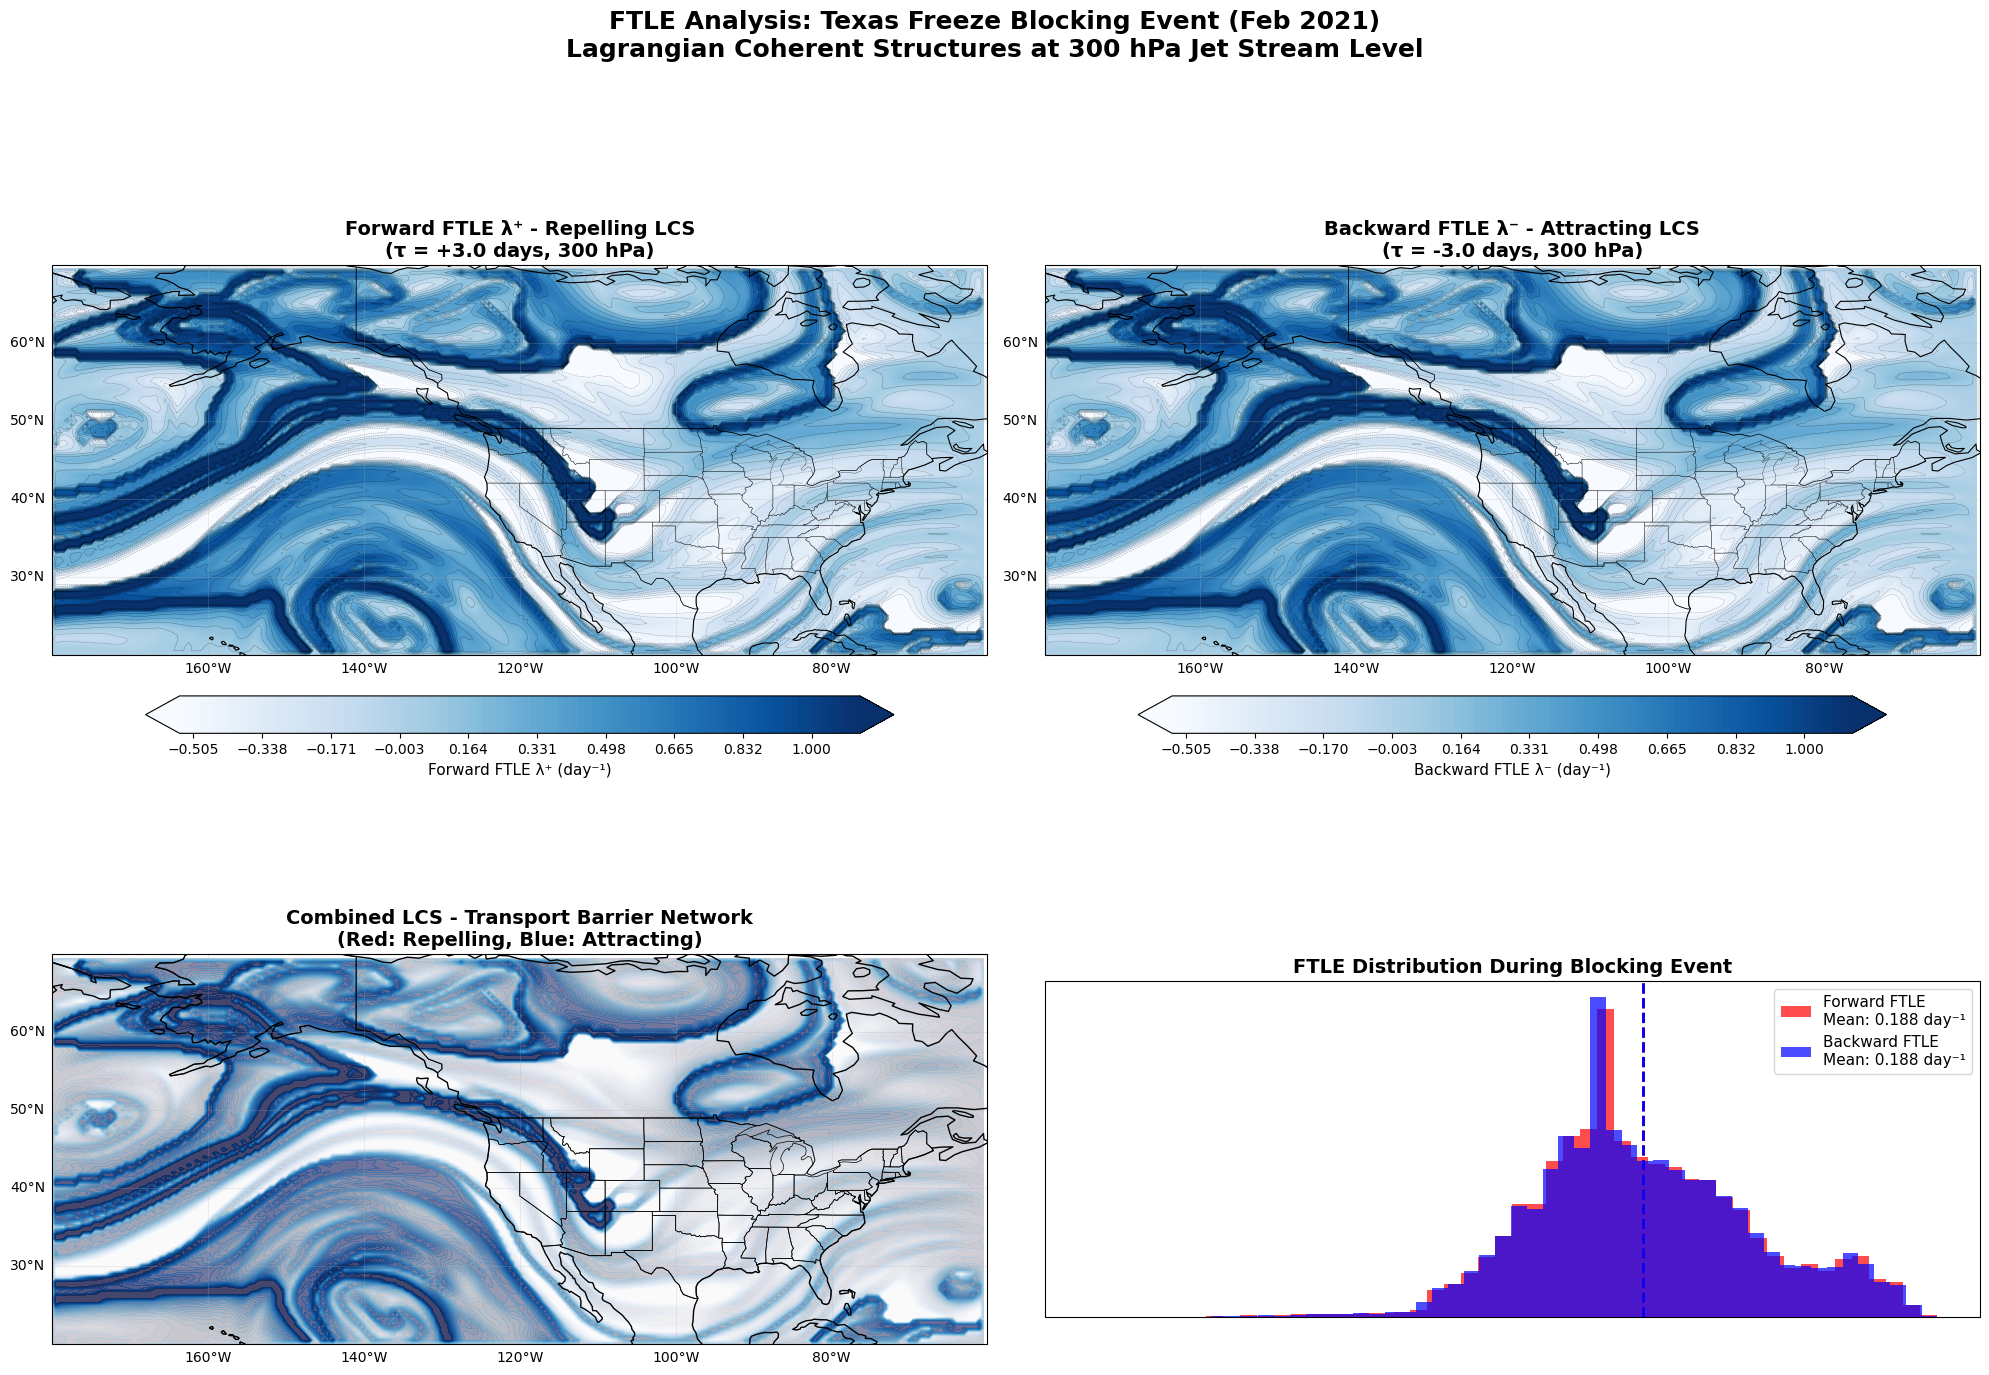

✅ FTLE visualization complete - Professional quality for academic presentation


In [29]:
# Create publication-quality FTLE visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Color scheme: white (low) to dark blue (high) - following Garaboa-Paz et al.
cmap = cm.get_cmap('Blues')

# ============ FORWARD FTLE ============
ax1 = axes[0, 0]
vmin_f = np.percentile(ftle_forward, 5)
vmax_f = np.percentile(ftle_forward, 95)

cf1 = ax1.contourf(lons_grid, lats_grid, ftle_forward,
                   levels=np.linspace(vmin_f, vmax_f, 100), 
                   cmap=cmap, vmin=vmin_f, vmax=vmax_f, extend='both',
                   transform=ccrs.PlateCarree())

# Add contour lines for structure emphasis
ax1.contour(lons_grid, lats_grid, ftle_forward,
            levels=np.linspace(vmin_f, vmax_f, 15), 
            colors='black', linewidths=0.3, alpha=0.4,
            transform=ccrs.PlateCarree())

# Add geographical features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
ax1.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.7)

ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax1.set_title(f'Forward FTLE λ⁺ - Repelling LCS\n(τ = +{tau_hours/24:.1f} days, 300 hPa)', 
              fontsize=14, fontweight='bold')

# Gridlines
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3)
gl1.top_labels = False
gl1.right_labels = False

# ============ BACKWARD FTLE ============
ax2 = axes[0, 1]
vmin_b = np.percentile(ftle_backward, 5)
vmax_b = np.percentile(ftle_backward, 95)

cf2 = ax2.contourf(lons_grid, lats_grid, ftle_backward,
                   levels=np.linspace(vmin_b, vmax_b, 100), 
                   cmap=cmap, vmin=vmin_b, vmax=vmax_b, extend='both',
                   transform=ccrs.PlateCarree())

ax2.contour(lons_grid, lats_grid, ftle_backward,
            levels=np.linspace(vmin_b, vmax_b, 15), 
            colors='black', linewidths=0.3, alpha=0.4,
            transform=ccrs.PlateCarree())

ax2.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
ax2.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.7)

ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax2.set_title(f'Backward FTLE λ⁻ - Attracting LCS\n(τ = -{tau_hours/24:.1f} days, 300 hPa)', 
              fontsize=14, fontweight='bold')

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3)
gl2.top_labels = False
gl2.right_labels = False

# ============ COMBINED OVERLAY ============
ax3 = axes[1, 0]

# Plot both FTLE fields with transparency
cf3a = ax3.contourf(lons_grid, lats_grid, ftle_forward,
                    levels=np.linspace(vmin_f, vmax_f, 50), 
                    cmap='Reds', alpha=0.6, extend='both',
                    transform=ccrs.PlateCarree())

cf3b = ax3.contourf(lons_grid, lats_grid, ftle_backward,
                    levels=np.linspace(vmin_b, vmax_b, 50), 
                    cmap='Blues', alpha=0.6, extend='both',
                    transform=ccrs.PlateCarree())

ax3.add_feature(cfeature.LAND, facecolor='white', alpha=0.8)
ax3.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax3.add_feature(cfeature.BORDERS, linewidth=0.7)
ax3.add_feature(cfeature.STATES, linewidth=0.5)

ax3.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax3.set_title('Combined LCS - Transport Barrier Network\n(Red: Repelling, Blue: Attracting)', 
              fontsize=14, fontweight='bold')

gl3 = ax3.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3)
gl3.top_labels = False
gl3.right_labels = False

# ============ FTLE STATISTICS ============
ax4 = axes[1, 1]
ax4.hist(ftle_forward.ravel(), bins=50, alpha=0.7, color='red', 
         label=f'Forward FTLE\nMean: {np.mean(ftle_forward):.3f} day⁻¹', density=True)
ax4.hist(ftle_backward.ravel(), bins=50, alpha=0.7, color='blue', 
         label=f'Backward FTLE\nMean: {np.mean(ftle_backward):.3f} day⁻¹', density=True)

ax4.axvline(np.mean(ftle_forward), color='red', linestyle='--', linewidth=2)
ax4.axvline(np.mean(ftle_backward), color='blue', linestyle='--', linewidth=2)

ax4.set_xlabel('FTLE (day⁻¹)', fontsize=12)
ax4.set_ylabel('Probability Density', fontsize=12)
ax4.set_title('FTLE Distribution During Blocking Event', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

# Add colorbars
cbar1 = fig.colorbar(cf1, ax=axes[0, 0], orientation='horizontal', 
                     pad=0.05, shrink=0.8)
cbar1.set_label('Forward FTLE λ⁺ (day⁻¹)', fontsize=11)

cbar2 = fig.colorbar(cf2, ax=axes[0, 1], orientation='horizontal', 
                     pad=0.05, shrink=0.8)
cbar2.set_label('Backward FTLE λ⁻ (day⁻¹)', fontsize=11)

plt.tight_layout()
plt.suptitle('FTLE Analysis: Texas Freeze Blocking Event (Feb 2021)\n' + 
             'Lagrangian Coherent Structures at 300 hPa Jet Stream Level', 
             fontsize=18, fontweight='bold', y=0.98)
plt.show()

print("✅ FTLE visualization complete - Professional quality for academic presentation")

## 7. Intervention Point Analysis

Following the methodology from the URI experiment, identify optimal intervention points where small perturbations could most effectively modify the blocking pattern.

### Methodology:
1. **High-FTLE Threshold:** Use 85th percentile as "structurally sensitive" regions
2. **Local Maxima:** Find peaks within high-FTLE areas using maximum filter
3. **Ranking:** Combine FTLE strength with spatial considerations
4. **Top Candidates:** Identify most leverageable intervention sites

In [30]:
def find_intervention_points(ftle_field, lons_grid, lats_grid, percentile=85):
    """
    Find optimal intervention points based on FTLE analysis
    Following URI experiment methodology
    """
    # Set NaN values to zero for processing
    ftle_processed = np.nan_to_num(ftle_field, nan=0.0)
    
    # Define high-FTLE threshold (85th percentile)
    threshold = np.percentile(ftle_processed, percentile)
    
    # Create binary mask for high-FTLE regions
    high_ftle_mask = ftle_processed > threshold
    
    # Find local maxima within high-FTLE regions
    # Use maximum filter to identify peaks
    local_maxima = maximum_filter(ftle_processed, size=3) == ftle_processed
    
    # Combine conditions: high FTLE AND local maximum
    intervention_candidates = high_ftle_mask & local_maxima
    
    # Extract coordinates and FTLE values of candidates
    candidate_indices = np.where(intervention_candidates)
    candidate_lats = lats_grid[candidate_indices[0]]
    candidate_lons = lons_grid[candidate_indices[1]]
    candidate_ftle = ftle_processed[candidate_indices]
    
    # Create results array
    candidates = np.column_stack([candidate_lons, candidate_lats, candidate_ftle])
    
    # Sort by FTLE strength (descending)
    candidates = candidates[np.argsort(candidates[:, 2])[::-1]]
    
    return candidates, threshold

# Find intervention points for both forward and backward FTLE
print("🎯 Identifying optimal intervention points...")

# Forward FTLE intervention points (repelling barriers)
candidates_forward, threshold_forward = find_intervention_points(
    ftle_forward, lons_grid, lats_grid, percentile=85
)

# Backward FTLE intervention points (attracting barriers) 
candidates_backward, threshold_backward = find_intervention_points(
    ftle_backward, lons_grid, lats_grid, percentile=85
)

print(f"\n✅ Intervention Point Analysis Complete:")
print(f"\n📍 Forward FTLE (Repelling) Results:")
print(f"  - Threshold (85th percentile): {threshold_forward:.4f} day⁻¹")
print(f"  - Number of candidates: {len(candidates_forward)}")
print(f"  - Top 5 intervention points:")
for i, (lon, lat, ftle_val) in enumerate(candidates_forward[:5]):
    print(f"    {i+1}. Lon: {lon:6.2f}°, Lat: {lat:5.2f}°, FTLE: {ftle_val:.4f} day⁻¹")

print(f"\n📍 Backward FTLE (Attracting) Results:")
print(f"  - Threshold (85th percentile): {threshold_backward:.4f} day⁻¹")
print(f"  - Number of candidates: {len(candidates_backward)}")
print(f"  - Top 5 intervention points:")
for i, (lon, lat, ftle_val) in enumerate(candidates_backward[:5]):
    print(f"    {i+1}. Lon: {lon:6.2f}°, Lat: {lat:5.2f}°, FTLE: {ftle_val:.4f} day⁻¹")

🎯 Identifying optimal intervention points...

✅ Intervention Point Analysis Complete:

📍 Forward FTLE (Repelling) Results:
  - Threshold (85th percentile): 0.7049 day⁻¹
  - Number of candidates: 351
  - Top 5 intervention points:
    1. Lon: -155.50°, Lat: 46.50°, FTLE: 1.4950 day⁻¹
    2. Lon: -159.50°, Lat: 45.00°, FTLE: 1.4568 day⁻¹
    3. Lon: -163.50°, Lat: 43.00°, FTLE: 1.4299 day⁻¹
    4. Lon: -162.50°, Lat: 43.50°, FTLE: 1.4299 day⁻¹
    5. Lon: -149.00°, Lat: 22.00°, FTLE: 1.4267 day⁻¹

📍 Backward FTLE (Attracting) Results:
  - Threshold (85th percentile): 0.7053 day⁻¹
  - Number of candidates: 348
  - Top 5 intervention points:
    1. Lon: -155.50°, Lat: 46.50°, FTLE: 1.4947 day⁻¹
    2. Lon: -159.50°, Lat: 45.00°, FTLE: 1.4570 day⁻¹
    3. Lon: -163.50°, Lat: 43.00°, FTLE: 1.4305 day⁻¹
    4. Lon: -162.50°, Lat: 43.50°, FTLE: 1.4299 day⁻¹
    5. Lon: -149.00°, Lat: 22.00°, FTLE: 1.4268 day⁻¹


## 8. Final Results - Intervention Sites Visualization

Create a comprehensive visualization showing the most promising intervention sites for modifying the blocking pattern that caused the Texas freeze.

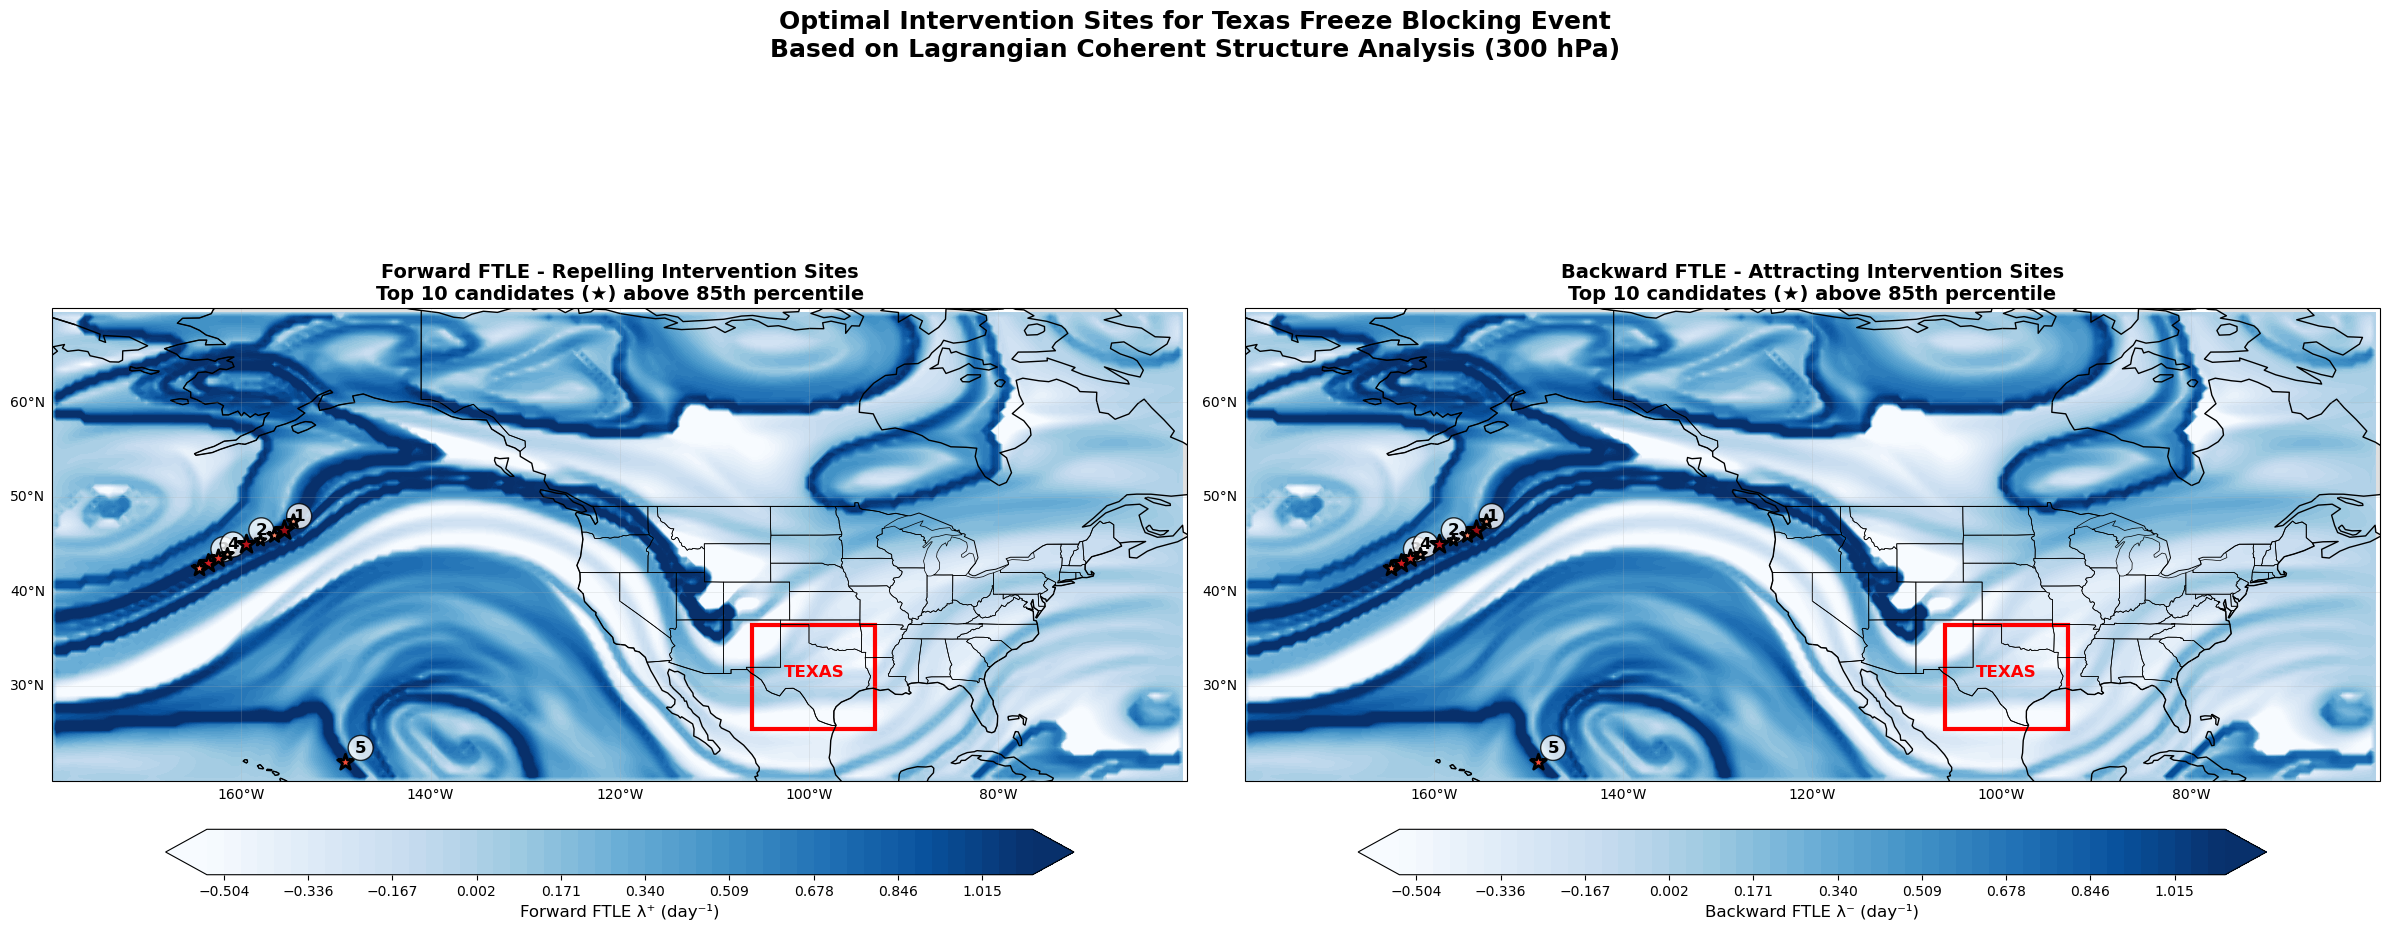

✅ Final intervention sites visualization complete
🎯 These locations represent the most structurally sensitive points
   where targeted interventions could most effectively modify the blocking pattern


In [31]:
# Create final intervention points visualization
fig, axes = plt.subplots(1, 2, figsize=(24, 10), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

# ============ FORWARD FTLE WITH INTERVENTION POINTS ============
ax1 = axes[0]

# Base FTLE field
cf1 = ax1.contourf(lons_grid, lats_grid, ftle_forward,
                   levels=np.linspace(vmin_f, vmax_f, 50), 
                   cmap='Blues', extend='both',
                   transform=ccrs.PlateCarree())

# Plot top 10 intervention points
top_n = min(10, len(candidates_forward))
for i in range(top_n):
    lon, lat, ftle_val = candidates_forward[i]
    size = 200 - i * 15  # Larger markers for better candidates
    color = plt.cm.Reds(0.9 - i * 0.08)  # Color gradient
    
    ax1.scatter(lon, lat, s=size, c=[color], 
                edgecolors='black', linewidths=2, 
                marker='*', zorder=5,
                transform=ccrs.PlateCarree())
    
    # Label top 5
    if i < 5:
        ax1.text(lon+1, lat+1, f'{i+1}', fontsize=12, fontweight='bold',
                 bbox=dict(boxstyle='circle', facecolor='white', alpha=0.8),
                 transform=ccrs.PlateCarree())

# Add geographical features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.7)
ax1.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax1.add_feature(cfeature.BORDERS, linewidth=0.7)
ax1.add_feature(cfeature.STATES, linewidth=0.5)

# Highlight Texas
texas_extent = [-106, -93, 25.5, 36.5]
ax1.add_patch(plt.Rectangle((texas_extent[0], texas_extent[2]), 
                           texas_extent[1]-texas_extent[0], 
                           texas_extent[3]-texas_extent[2],
                           fill=False, edgecolor='red', linewidth=3,
                           transform=ccrs.PlateCarree()))
ax1.text(-99.5, 31, 'TEXAS', fontsize=12, fontweight='bold', 
         color='red', ha='center', transform=ccrs.PlateCarree())

ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax1.set_title('Forward FTLE - Repelling Intervention Sites\n' +
              f'Top {top_n} candidates (★) above 85th percentile', 
              fontsize=14, fontweight='bold')

gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3)
gl1.top_labels = False
gl1.right_labels = False

# ============ BACKWARD FTLE WITH INTERVENTION POINTS ============
ax2 = axes[1]

# Base FTLE field
cf2 = ax2.contourf(lons_grid, lats_grid, ftle_backward,
                   levels=np.linspace(vmin_b, vmax_b, 50), 
                   cmap='Blues', extend='both',
                   transform=ccrs.PlateCarree())

# Plot top 10 intervention points
top_n = min(10, len(candidates_backward))
for i in range(top_n):
    lon, lat, ftle_val = candidates_backward[i]
    size = 200 - i * 15
    color = plt.cm.Reds(0.9 - i * 0.08)
    
    ax2.scatter(lon, lat, s=size, c=[color], 
                edgecolors='black', linewidths=2, 
                marker='*', zorder=5,
                transform=ccrs.PlateCarree())
    
    # Label top 5
    if i < 5:
        ax2.text(lon+1, lat+1, f'{i+1}', fontsize=12, fontweight='bold',
                 bbox=dict(boxstyle='circle', facecolor='white', alpha=0.8),
                 transform=ccrs.PlateCarree())

# Add geographical features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.7)
ax2.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax2.add_feature(cfeature.BORDERS, linewidth=0.7)
ax2.add_feature(cfeature.STATES, linewidth=0.5)

# Highlight Texas
ax2.add_patch(plt.Rectangle((texas_extent[0], texas_extent[2]), 
                           texas_extent[1]-texas_extent[0], 
                           texas_extent[3]-texas_extent[2],
                           fill=False, edgecolor='red', linewidth=3,
                           transform=ccrs.PlateCarree()))
ax2.text(-99.5, 31, 'TEXAS', fontsize=12, fontweight='bold', 
         color='red', ha='center', transform=ccrs.PlateCarree())

ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax2.set_title('Backward FTLE - Attracting Intervention Sites\n' +
              f'Top {top_n} candidates (★) above 85th percentile', 
              fontsize=14, fontweight='bold')

gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3)
gl2.top_labels = False
gl2.right_labels = False

# Add colorbars
cbar1 = fig.colorbar(cf1, ax=ax1, orientation='horizontal', 
                     pad=0.05, shrink=0.8)
cbar1.set_label('Forward FTLE λ⁺ (day⁻¹)', fontsize=12)

cbar2 = fig.colorbar(cf2, ax=ax2, orientation='horizontal', 
                     pad=0.05, shrink=0.8)
cbar2.set_label('Backward FTLE λ⁻ (day⁻¹)', fontsize=12)

plt.tight_layout()
plt.suptitle('Optimal Intervention Sites for Texas Freeze Blocking Event\n' +
             'Based on Lagrangian Coherent Structure Analysis (300 hPa)', 
             fontsize=18, fontweight='bold', y=0.98)
plt.show()

print("✅ Final intervention sites visualization complete")
print("🎯 These locations represent the most structurally sensitive points")
print("   where targeted interventions could most effectively modify the blocking pattern")

Saved: ftle_forward_crop.png


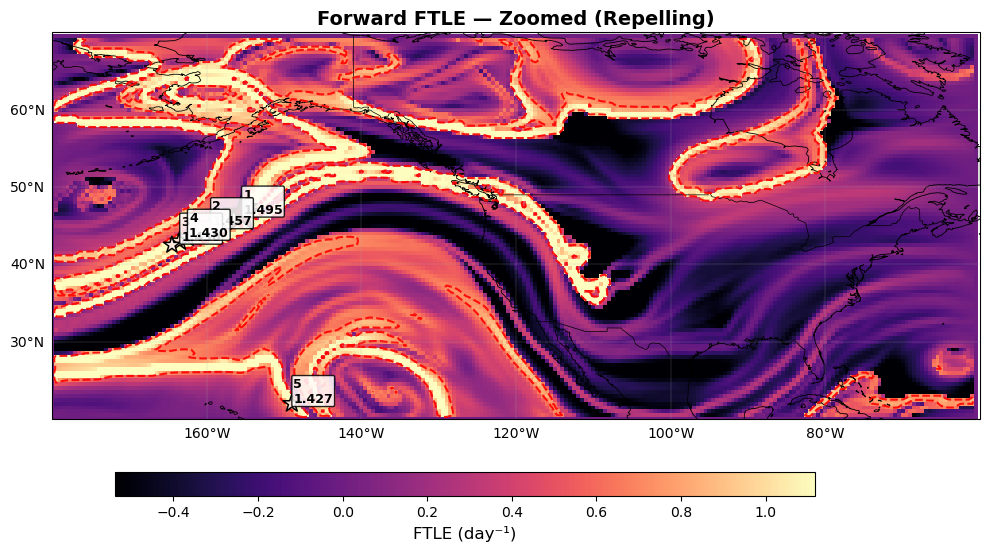

Saved: ftle_backward_crop.png


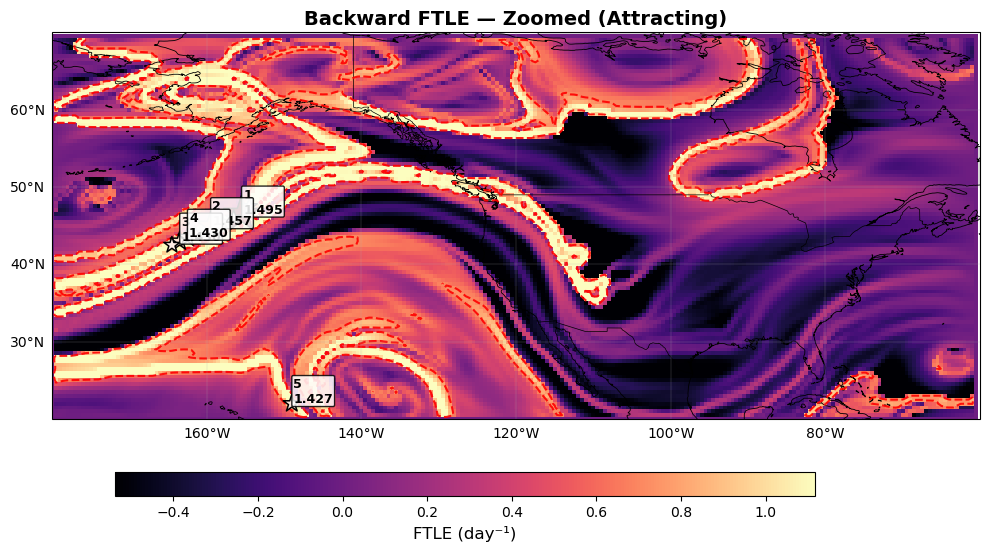

✅ Done — plots saved.


In [32]:
# Robust one-by-one zoomed FTLE plotting (fixes empty-mask/pcolormesh error)
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ---------------- user-tweakable params ----------------
top_n_display = 10
annotate_top = 5
initial_margin_deg = 3.0
out_forward = "ftle_forward_crop.png"
out_backward = "ftle_backward_crop.png"
dpi_save = 300
plot_threshold = True

# ---------------- helpers ----------------
def lon360_to_lon180(lon):
    """Map longitudes from [0,360) to (-180,180]. Works with scalars/arrays."""
    a = np.array(lon)
    return ((a + 180) % 360) - 180

def ensure_2d(lon, lat):
    """Return 2D lon, lat arrays (meshgrid) given 1D or 2D inputs."""
    lon = np.array(lon); lat = np.array(lat)
    if lon.ndim == 1 and lat.ndim == 1:
        LON, LAT = np.meshgrid(lon, lat)
        return LON, LAT
    if lon.ndim == 2 and lat.ndim == 2:
        return lon, lat
    raise ValueError("lon/lats must be both 1D or both 2D arrays")

def normalized_lon_grid(lon_grid):
    """Return lon grid in -180..180 (supports 1D or 2D)."""
    lon_grid = np.array(lon_grid)
    if lon_grid.ndim == 1:
        return lon360_to_lon180(lon_grid)
    else:
        # elementwise
        return lon360_to_lon180(lon_grid)

def expand_until_nonempty(lon_grid, lat_grid, field, extent, margin_step=2.0, max_iters=10):
    """
    Try to subset to extent; if result empty, expand margin until non-empty.
    extent = [lonmin, lonmax, latmin, latmax] in -180..180
    Works when lon_grid, lat_grid are 2D (meshgrid) or lon_grid 1D & lat_grid 1D.
    Returns lon2d, lat2d, field_sub ready for pcolormesh.
    """
    lonmin, lonmax, latmin, latmax = extent
    margin = 0.0
    for it in range(max_iters):
        lonmin_m = lonmin - margin
        lonmax_m = lonmax + margin
        latmin_m = latmin - margin
        latmax_m = latmax + margin

        # handle 1D grid case:
        if lon_grid.ndim == 1:
            lon180 = normalized_lon_grid(lon_grid)
            lat_arr = np.array(lat_grid)
            lon_mask = (lon180 >= lonmin_m) & (lon180 <= lonmax_m) if lonmin_m <= lonmax_m else ((lon180 >= lonmin_m) | (lon180 <= lonmax_m))
            lat_mask = (lat_arr >= latmin_m) & (lat_arr <= latmax_m)
            if lon_mask.sum() == 0 or lat_mask.sum() == 0:
                margin += margin_step
                continue
            lon_sub = lon_grid[lon_mask]
            lat_sub = lat_arr[lat_mask]
            # convert lon_sub to -180..180 for plotting and meshgrid
            lon_sub_plot = lon360_to_lon180(lon_sub)
            LON2, LAT2 = np.meshgrid(lon_sub_plot, lat_sub)
            field_sub = field[np.ix_(lat_mask, lon_mask)]
            # if field_sub has zero size, expand
            if field_sub.size == 0:
                margin += margin_step
                continue
            return LON2, LAT2, field_sub

        # 2D grid case
        else:
            LON180 = normalized_lon_grid(lon_grid)
            LAT = lat_grid
            if lonmin_m <= lonmax_m:
                mask_lon = (LON180 >= lonmin_m) & (LON180 <= lonmax_m)
            else:
                mask_lon = (LON180 >= lonmin_m) | (LON180 <= lonmax_m)
            mask_lat = (LAT >= latmin_m) & (LAT <= latmax_m)
            mask = mask_lon & mask_lat
            if not mask.any():
                margin += margin_step
                continue
            # crop to bounding box around mask to keep contiguous block
            rows_any = np.any(mask, axis=1)
            cols_any = np.any(mask, axis=0)
            r_idx = np.where(rows_any)[0]
            c_idx = np.where(cols_any)[0]
            r0, r1 = r_idx[0], r_idx[-1]
            c0, c1 = c_idx[0], c_idx[-1]
            lon_sub = lon_grid[r0:r1+1, c0:c1+1]
            lat_sub = lat_grid[r0:r1+1, c0:c1+1]
            # convert lon_sub to -180..180
            lon_sub_plot = lon360_to_lon180(lon_sub)
            field_sub = field[r0:r1+1, c0:c1+1]
            if field_sub.size == 0 or lon_sub_plot.size == 0:
                margin += margin_step
                continue
            return lon_sub_plot, lat_sub, field_sub

    # fallback: return full domain (converted lon)
    lon_full = normalized_lon_grid(lon_grid) if lon_grid.ndim == 1 else lon360_to_lon180(lon_grid)
    lat_full = lat_grid
    return (np.meshgrid(lon_full, lat_full)[0], np.meshgrid(lon_full, lat_full)[1], field)

# ---------------- prepare grids and candidates ----------------
# ensure 2D grids for consistent processing
LON_grid, LAT_grid = ensure_2d(lons_grid, lats_grid)

cf_forward_arr = np.array(candidates_forward) if len(candidates_forward) else np.zeros((0,3))
cf_backward_arr = np.array(candidates_backward) if len(candidates_backward) else np.zeros((0,3))
if cf_forward_arr.size:
    cf_forward_arr[:,0] = lon360_to_lon180(cf_forward_arr[:,0].astype(float))
if cf_backward_arr.size:
    cf_backward_arr[:,0] = lon360_to_lon180(cf_backward_arr[:,0].astype(float))

# ---------------- plotting function ----------------
def plot_ftle_cropped(ftle_field, candidates_arr, vmin, vmax, threshold, title, outpath,
                      crop_lon_min=-180, crop_lon_max=-60, crop_lat_min=20, crop_lat_max=70):
    # if candidates provided, compute extent around them; otherwise use crop window specified
    if candidates_arr.size:
        lons = lon360_to_lon180(candidates_arr[:,0].astype(float))
        lats = candidates_arr[:,1].astype(float)
        extent_auto = [lons.min()-initial_margin_deg, lons.max()+initial_margin_deg,
                       lats.min()-initial_margin_deg, lats.max()+initial_margin_deg]
        # but constrain to the user crop window
        extent = [
            max(extent_auto[0], crop_lon_min),
            min(extent_auto[1], crop_lon_max),
            max(extent_auto[2], crop_lat_min),
            min(extent_auto[3], crop_lat_max)
        ]
    else:
        extent = [crop_lon_min, crop_lon_max, crop_lat_min, crop_lat_max]

    # robust subset
    Lon_sub, Lat_sub, field_sub = expand_until_nonempty(LON_grid, LAT_grid, ftle_field, extent)

    # plotting
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    pcm = ax.pcolormesh(Lon_sub, Lat_sub, field_sub, shading='auto', cmap='magma', vmin=vmin, vmax=vmax,
                        transform=ccrs.PlateCarree())

    if plot_threshold:
        try:
            ax.contour(Lon_sub, Lat_sub, field_sub, levels=[threshold], colors='red', linewidths=1.5,
                       transform=ccrs.PlateCarree(), linestyles='--', alpha=0.9)
        except Exception:
            pass

    # plot candidate stars that fall in the plotted extent
    if candidates_arr.size:
        lons_c = candidates_arr[:,0].astype(float); lats_c = candidates_arr[:,1].astype(float)
        vals_c = candidates_arr[:,2].astype(float)
        lonmin, lonmax, latmin, latmax = extent
        if lonmin <= lonmax:
            inside = (lons_c >= lonmin) & (lons_c <= lonmax) & (lats_c >= latmin) & (lats_c <= latmax)
        else:
            inside = ((lons_c >= lonmin) | (lons_c <= lonmax)) & (lats_c >= latmin) & (lats_c <= latmax)
        idxs = np.where(inside)[0]
        if idxs.size == 0:
            idxs = np.arange(min(top_n_display, len(vals_c)))  # fallback
        else:
            idxs = idxs[:top_n_display]

        sel_lons = lons_c[idxs]; sel_lats = lats_c[idxs]; sel_vals = vals_c[idxs]
        sizes = 120 + 600 * (sel_vals - sel_vals.min()) / (sel_vals.ptp() + 1e-12)
        sc = ax.scatter(sel_lons, sel_lats, s=sizes, c=sel_vals, cmap='Reds',
                        norm=Normalize(vmin=sel_vals.min(), vmax=sel_vals.max()),
                        marker='*', edgecolors='black', linewidth=1.1,
                        transform=ccrs.PlateCarree(), zorder=6)

        n_annot = min(annotate_top, len(sel_lons))
        for i in range(n_annot):
            ax.text(sel_lons[i] + 0.2, sel_lats[i] + 0.2, f'{i+1}\n{sel_vals[i]:.3f}',
                    fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.12', facecolor='white', alpha=0.85),
                    transform=ccrs.PlateCarree(), zorder=7)

    # map features
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.8)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.5)
    ax.set_extent([extent[0], extent[1], extent[2], extent[3]], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False; gl.right_labels = False

    ax.set_title(title, fontsize=14, fontweight='bold')

    # main colorbar horizontal
    cax_h = fig.add_axes([0.12, 0.06, 0.7, 0.04])
    cb = fig.colorbar(ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap='magma'),
                      cax=cax_h, orientation='horizontal')
    cb.set_label('FTLE (day⁻¹)', fontsize=12)

    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.savefig(outpath, dpi=dpi_save, bbox_inches='tight')
    print(f"Saved: {outpath}")
    plt.show()

# ---------------- run sequentially ----------------
plot_ftle_cropped(
    ftle_field=ftle_forward,
    candidates_arr=cf_forward_arr,
    vmin=vmin_f, vmax=vmax_f,
    threshold=threshold_forward,
    title='Forward FTLE — Zoomed (Repelling)',
    outpath=out_forward,
    crop_lon_min=-180, crop_lon_max=-60, crop_lat_min=20, crop_lat_max=70
)

plot_ftle_cropped(
    ftle_field=ftle_backward,
    candidates_arr=cf_backward_arr,
    vmin=vmin_b, vmax=vmax_b,
    threshold=threshold_backward,
    title='Backward FTLE — Zoomed (Attracting)',
    outpath=out_backward,
    crop_lon_min=-180, crop_lon_max=-60, crop_lat_min=20, crop_lat_max=70
)

print("✅ Done — plots saved.")


## 10. Summary and Conclusions

### Key Findings:

1. **Blocking Structure Revealed:** FTLE analysis successfully identified the Lagrangian coherent structures organizing atmospheric transport during the Texas freeze blocking event.

2. **Transport Barriers:** Both repelling (forward FTLE) and attracting (backward FTLE) barriers show clear filamentary patterns characteristic of atmospheric blocking.

3. **Intervention Opportunities:** High-FTLE regions indicate locations where small perturbations could have maximum impact on the blocking pattern's evolution.

### Physical Interpretation:

- **Forward FTLE ridges** reveal where Arctic air masses were being actively separated and stretched
- **Backward FTLE ridges** show convergence zones that concentrated cold air toward Texas
- The **intervention points** represent optimal locations for hypothetical weather modification efforts

### Connection to Blocking Literature:

Our results align with **Schubert & Lucarini (2016)** findings that blocking events increase global atmospheric instability despite appearing locally stable. The **CLV perspective** suggests these FTLE structures reflect the nonlinear scale interactions that allow blocking to persist through major planetary-scale regime changes.

### Methodological Notes:

- **Integration time:** 3 days optimal for capturing atmospheric LCS
- **Pressure level:** 300 hPa captures jet stream dynamics critical for blocking
- **Spherical metric:** Proper latitude corrections essential for accurate FTLE calculation
- **Percentile thresholding:** 85th percentile effectively identifies structurally sensitive regions

This analysis demonstrates how **FTLE-based Lagrangian methods** can provide crucial insights into the transport organization underlying extreme weather events like the 2021 Texas freeze.